# CONVOLUTIONAL AE TRAINING

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import h5py

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

2026-06-23 08:19:44.380633: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 08:19:44.461638: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
BACKGROUND_FILE = "../data/datasets/convolutional/background_convolutional_dataset.h5"

with h5py.File(BACKGROUND_FILE, "r") as f:
    X_train = f["X_train"][:].astype(np.float32)
    X_val = f["X_val"][:].astype(np.float32)
    X_test = f["X_test"][:].astype(np.float32)

print(f'{"X_train":<10}: {X_train.shape}')
print(f'{"X_val":<10}: {X_val.shape}')
print(f'{"X_test":<10}: {X_test.shape}')

# Conv2D expects a channel axis.
X_train_c = X_train[..., np.newaxis]
X_val_c = X_val[..., np.newaxis]
X_test_c = X_test[..., np.newaxis]

print(f'{"X_train_c":<10}: {X_train_c.shape}')
print(f'{"X_val_c":<10}: {X_val_c.shape}')
print(f'{"X_test_c":<10}: {X_test_c.shape}')

X_train   : (8609225, 19, 3)
X_val     : (2152307, 19, 3)
X_test    : (2690383, 19, 3)
X_train_c : (8609225, 19, 3, 1)
X_val_c   : (2152307, 19, 3, 1)
X_test_c  : (2690383, 19, 3, 1)


In [3]:
CONV_MODELS_DIR = "../models/convolutional_AE"
os.makedirs(CONV_MODELS_DIR, exist_ok=True)

MODEL_NAME = "conv2d_ae_5"

SAVE_MODEL_PATH = os.path.join(CONV_MODELS_DIR, f"{MODEL_NAME}.keras")

In [4]:
N_OBJ = 19

PT_STD = X_train[:, :, 0].std() + 1e-8

In [5]:
W_CURR = {"pt": 1.0, "eta": 1.0, "phi": 0.5}

def masked_trigger_loss(y_true, y_pred):
    batch_size = tf.shape(y_true)[0]
    y_true = tf.reshape(y_true, (batch_size, 19, 3))
    y_pred = tf.reshape(y_pred, (batch_size, 19, 3))

    '''
    same as
    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))
    but compatible with keras on SWAN
    '''

    # object exists iff pT != 0
    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (PT_STD ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = W_CURR["pt"] * pt_loss + W_CURR["eta"] * eta_loss + W_CURR["phi"] * phi_loss
    total *= mask

    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)
    return tf.reduce_mean(tf.reduce_sum(total, axis=[1, 2]) / n_present)

In [6]:
'''
def build_conv_ae(input_shape=(19, 3, 1), latent_dim=48, name="conv_ae"):
    inp = keras.Input(shape=input_shape, name="input")

    # Paper-inspired idea: separate mixing on feature axis (pt/eta/phi) and object axis.
    x = layers.Conv2D(16, (1, 3), padding="same", use_bias=False)(inp)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(16, (3, 1), padding="same", use_bias=False)(x)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)
    skip = x

    x = layers.Conv2D(32, (3, 1), strides=(2, 1), padding="same", use_bias=False)(x)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(64, (3, 1), padding="same", use_bias=False)(x)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name="latent")(x)

    x = layers.Dense(10 * 3 * 64, use_bias=False)(z)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Reshape((10, 3, 64))(x)

    x = layers.Conv2D(64, (3, 1), padding="same", use_bias=False)(x)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.UpSampling2D((2, 1))(x)
    x = layers.Conv2D(32, (3, 1), padding="same", use_bias=False)(x)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(16, (1, 3), padding="same", use_bias=False)(x)
    x = layers.LayerNormalization(axis=[1, 2, 3])(x)
    x = layers.LeakyReLU(0.1)(x)

    # 20 -> 19 after upsampling, then add a shallow skip for low-level details.
    x = layers.Cropping2D(cropping=((0, 1), (0, 0)))(x)
    skip_proj = layers.Conv2D(16, (1, 1), padding="same", use_bias=False)(skip)
    x = layers.Add()([x, skip_proj])

    out = layers.Conv2D(1, (1, 1), padding="same", name="reco")(x)
    return Model(inp, out, name=name)

conv_ae = build_conv_ae(name=MODEL_NAME)
conv_ae.summary()
'''

'\ndef build_conv_ae(input_shape=(19, 3, 1), latent_dim=48, name="conv_ae"):\n    inp = keras.Input(shape=input_shape, name="input")\n\n    # Paper-inspired idea: separate mixing on feature axis (pt/eta/phi) and object axis.\n    x = layers.Conv2D(16, (1, 3), padding="same", use_bias=False)(inp)\n    x = layers.LayerNormalization(axis=[1, 2, 3])(x)\n    x = layers.LeakyReLU(0.1)(x)\n\n    x = layers.Conv2D(16, (3, 1), padding="same", use_bias=False)(x)\n    x = layers.LayerNormalization(axis=[1, 2, 3])(x)\n    x = layers.LeakyReLU(0.1)(x)\n    skip = x\n\n    x = layers.Conv2D(32, (3, 1), strides=(2, 1), padding="same", use_bias=False)(x)\n    x = layers.LayerNormalization(axis=[1, 2, 3])(x)\n    x = layers.LeakyReLU(0.1)(x)\n\n    x = layers.Conv2D(64, (3, 1), padding="same", use_bias=False)(x)\n    x = layers.LayerNormalization(axis=[1, 2, 3])(x)\n    x = layers.LeakyReLU(0.1)(x)\n\n    x = layers.Flatten()(x)\n    z = layers.Dense(latent_dim, name="latent")(x)\n\n    x = layers.Dens

In [7]:
def build_conv_ae(input_shape=(19, 3, 1), latent_dim=8, name="conv_ae"):
    """
    Convolutional Autoencoder architecture from paper
    
    Encoder: Zero-pad → Conv2D(16) → Conv2D(32) + AvgPool → Flatten → Dense(8)
    Decoder: Dense(64) → Reshape → UpSample + Conv(32) → UpSample + Conv(16) → Conv(1) + Crop
    """
    inp = keras.Input(shape=input_shape, name="input")
    
    # Block 0: zero-pad to (20,3,1) + BatchNorm
    x = layers.ZeroPadding2D(padding=((1, 0), (0, 0)))(inp)
    x = layers.BatchNormalization()(x)
    
    # Block 1: Conv2D 16 × (3,3) with valid padding
    x = layers.Conv2D(16, (3, 3), padding="valid", use_bias=False, activation="relu")(x)  # (18,1,16)
    
    # Block 2: Conv2D 32 × (3,1) + AveragePooling
    x = layers.Conv2D(32, (3, 1), padding="same", use_bias=False, activation="relu")(x)   # (18,1,32)
    x = layers.AveragePooling2D((3, 1))(x)  # (6,1,32)
    
    # Flatten → latent
    flat = layers.Flatten()(x)  # 192
    z = layers.Dense(latent_dim, name="latent")(flat)
    
    # Decoder
    x = layers.Dense(64, activation="relu")(z)
    x = layers.Reshape((2, 1, 32))(x)
    
    # Block 4: UpSample + Conv
    x = layers.UpSampling2D((3, 1))(x)  # (6,1,32)
    x = layers.ZeroPadding2D(((0, 0), (1, 1)))(x)
    x = layers.Conv2D(32, (3, 1), padding="same", use_bias=False, activation="relu")(x)
    
    # Block 5: UpSample + Conv
    x = layers.UpSampling2D((3, 1))(x)  # (18,3,32)
    x = layers.ZeroPadding2D(((1, 0), (0, 0)))(x)
    x = layers.Conv2D(16, (3, 1), padding="same", use_bias=False, activation="relu")(x)
    
    # Output
    x = layers.UpSampling2D((1, 1))(x)
    out_pad = layers.Conv2D(1, (3, 3), padding="same")(x)  # (20,3,1)
    out = layers.Cropping2D(cropping=((0, 0), (0, 0)))(out_pad)  # (19,3,1)
    
    return Model(inp, out, name=name)

conv_ae = build_conv_ae(name=MODEL_NAME)
conv_ae.summary()

I0000 00:00:1782195607.733881   35683 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Model: "conv_ae_5_mse"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 19, 3, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 20, 3, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 3, 1)       │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 18, 1, 16)      │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 1, 32)      │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 6, 1, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │         1,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 6, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 6, 3, 32)       │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 3, 32)       │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 18, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_2                │ (None, 19, 3, 32)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 3, 16)      │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 19, 3, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 3, 1)       │           145 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 19, 3, 1)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,557 (33.43 KB)

 Trainable params: 8,555 (33.42 KB)

 Non-trainable params: 2 (8.00 B)

In [8]:
EPOCHS = 100
BATCH_SIZE = 1024
LR = 1e-3

conv_ae.compile(optimizer=keras.optimizers.Adam(LR), loss=masked_trigger_loss)

cb = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    keras.callbacks.ModelCheckpoint(SAVE_MODEL_PATH, save_best_only=True),
]

history_cae = conv_ae.fit(
    X_train_c,
    X_train_c,
    validation_data=(X_val_c, X_val_c),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    verbose=1,
)

Epoch 1/100


2026-06-23 08:20:20.008141: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fea2801ddf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-23 08:20:20.008177: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-06-23 08:20:20.076559: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-23 08:20:20.438576: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


  29/8408 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 120.0362

I0000 00:00:1782195623.348896   35812 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8408/8408 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.4169

2026-06-23 08:21:12.457171: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[1024,16,18,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[1024,1,20,3]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-06-23 08:21:19.238562: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[883,16,18,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[883,1,20,3]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

8408/8408 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 2.7976 - val_loss: 2.1024 - learning_rate: 0.0010
Epoch 2/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.6414 - val_loss: 1.0148 - learning_rate: 0.0010
Epoch 3/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.5467 - val_loss: 0.8751 - learning_rate: 0.0010
Epoch 4/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.5180 - val_loss: 0.7735 - learning_rate: 0.0010
Epoch 5/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.4999 - val_loss: 0.6891 - learning_rate: 0.0010
Epoch 6/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.4879 - val_loss: 0.6614 - learning_rate: 0.0010
Epoch 7/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.4778 - val_loss: 0.6688 - learning_rate: 0.0010
Epoch 8/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 0.4657 - val_loss: 0.6311 - learning_rate: 0.0010
Epoch 9/100
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.4558 - val_loss: 0.6197 - learning

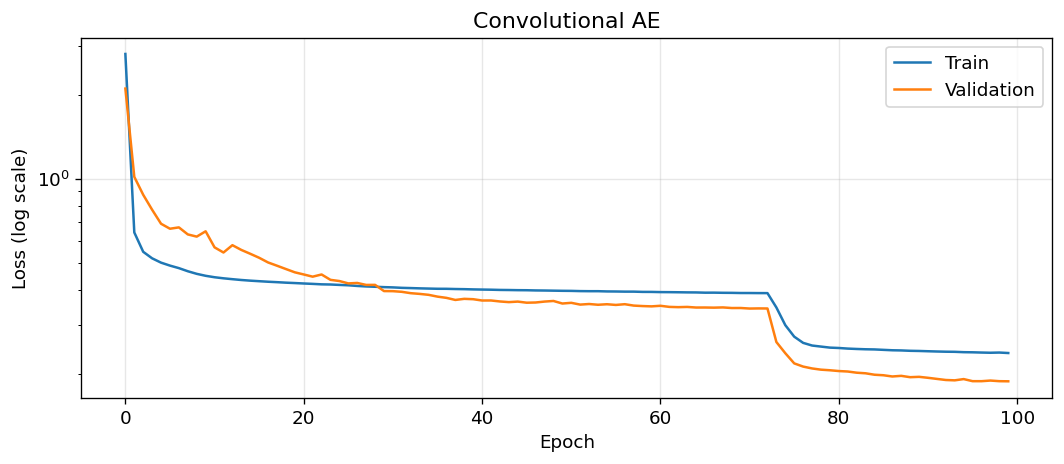

In [9]:
def plot_history(history, title="Training history"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(history.history["loss"], label="Train")
    ax.semilogy(history.history["val_loss"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cae, "Convolutional AE")

In [10]:
def _ensure_channel_axis(X):
    return X[..., np.newaxis] if X.ndim == 3 else X

def compute_masked_components_arrays(model, X, batch_size=8192):
    X_in = _ensure_channel_axis(X)
    y_true = tf.convert_to_tensor(X_in, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(model.predict(X_in, batch_size=batch_size, verbose=0), dtype=tf.float32)

    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (PT_STD ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    pt_evt = tf.reduce_sum(pt_loss * mask, axis=[1, 2]) / n_present
    eta_evt = tf.reduce_sum(eta_loss * mask, axis=[1, 2]) / n_present
    phi_evt = tf.reduce_sum(phi_loss * mask, axis=[1, 2]) / n_present

    return {
        "pt_evt": pt_evt.numpy(),
        "eta_evt": eta_evt.numpy(),
        "phi_evt": phi_evt.numpy(),
    }

def summarize_components(comp, weights):
    pt_m = float(np.mean(comp["pt_evt"]))
    eta_m = float(np.mean(comp["eta_evt"]))
    phi_m = float(np.mean(comp["phi_evt"]))

    pt_w = weights["pt"] * pt_m
    eta_w = weights["eta"] * eta_m
    phi_w = weights["phi"] * phi_m
    tot_w = pt_w + eta_w + phi_w

    return {
        "unweighted_mean": {"pt": pt_m, "eta": eta_m, "phi": phi_m},
        "weighted_mean": {"pt": pt_w, "eta": eta_w, "phi": phi_w, "total": tot_w},
        "weighted_fraction": {
            "pt": pt_w / (tot_w + 1e-12),
            "eta": eta_w / (tot_w + 1e-12),
            "phi": phi_w / (tot_w + 1e-12),
        },
    }

def print_summary(split_name, summary):
    print(f"\n=== {split_name} ===")
    print("Unweighted means:")
    print(
        f"  pt={summary['unweighted_mean']['pt']:.6f}, "
        f"eta={summary['unweighted_mean']['eta']:.6f}, "
        f"phi={summary['unweighted_mean']['phi']:.6f}"
    )
    print("Weighted means:")
    print(
        f"  pt={summary['weighted_mean']['pt']:.6f}, "
        f"eta={summary['weighted_mean']['eta']:.6f}, "
        f"phi={summary['weighted_mean']['phi']:.6f}, "
        f"total={summary['weighted_mean']['total']:.6f}"
    )
    print("Weighted fractions:")
    print(
        f"  pt={summary['weighted_fraction']['pt']:.3f}, "
        f"eta={summary['weighted_fraction']['eta']:.3f}, "
        f"phi={summary['weighted_fraction']['phi']:.3f}"
    )

comp_train = compute_masked_components_arrays(conv_ae, X_train_c)
comp_val = compute_masked_components_arrays(conv_ae, X_val_c)

summary_train = summarize_components(comp_train, W_CURR)
summary_val = summarize_components(comp_val, W_CURR)

print_summary("TRAIN", summary_train)
print_summary("VAL", summary_val)

2026-06-23 09:45:47.098721: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[8192,16,18,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[8192,1,20,3]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-06-23 09:45:54.042251: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[7625,16,18,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[7625,1,20,3]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF


=== TRAIN ===
Unweighted means:
  pt=0.001698, eta=0.182247, phi=0.350883
Weighted means:
  pt=0.001698, eta=0.182247, phi=0.175441, total=0.359387
Weighted fractions:
  pt=0.005, eta=0.507, phi=0.488

=== VAL ===
Unweighted means:
  pt=0.001688, eta=0.182144, phi=0.350767
Weighted means:
  pt=0.001688, eta=0.182144, phi=0.175383, total=0.359215
Weighted fractions:
  pt=0.005, eta=0.507, phi=0.488
